# Alzheimer's Disease Brain MRI — Multi-Class Tissue Segmentation
## SegNet | 4-Class (Background / CSF / Grey Matter / White Matter) | IBSR Dataset

**Dataset:** Internet Brain Segmentation Repository (IBSR) — 18 subjects, expert-annotated tri-class tissue segmentation (`segTRI`).

**Architecture:** SegNet uses VGG16-style encoder blocks with **max-pooling indices** passed to decoder upsampling layers — no skip-connection concatenation. This yields a leaner model than UNet while preserving spatial detail via index-guided unpooling.

**Why multi-class directly (no binary step):** The binary-then-multiclass pipeline was already validated on OASIS-1. Since IBSR's `segTRI` masks use the same 4-label convention (0=background, 1=CSF, 2=GM, 3=WM), we go directly to multi-class here.

**Note:** EarlyStopping disabled — model trains for the full configured epochs as instructed.

**Note on CSF class:** IBSR's CSF label is far sparser (~0.17% of voxels) than OASIS-1's (~7.5%) — expect CSF IoU to be a harder, noisier metric here purely due to extreme class imbalance, not a pipeline issue.

## 1. Import Libraries

In [84]:
import os
import re
import cv2
import random
import shutil
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    BatchNormalization, Activation, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration & Extraction

In [85]:
# ─── Paths — adjust dataset slug if different ─────────────────────────────────
IBSR_TGZ_PATH = '/kaggle/input/datasets/maheswarimudadla/ibsr-dataset/IBSR_V2.0_nifti_stripped.tgz'
EXTRACT_DIR   = '/kaggle/working/ibsr_extracted'
IBSR_ROOT     = os.path.join(EXTRACT_DIR, 'IBSR_nifti_stripped')

PROCESSED_DIR   = 'ibsr_processed'
IMAGE_FOLDER    = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER     = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR   = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR  = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR    = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR   = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.15
NUM_CLASSES = 4   # 0=background, 1=CSF, 2=Grey Matter, 3=White Matter
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

print('Config set ✓')

Config set ✓


In [86]:
# ─── Extract the .tgz if not already done ─────────────────────────────────────
if not os.path.exists(IBSR_ROOT):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print('Extracting IBSR archive...')
    with tarfile.open(IBSR_TGZ_PATH, 'r:gz') as tar:
        tar.extractall(path=EXTRACT_DIR)
    print('Extraction done ✓')
else:
    print('Already extracted ✓')

subject_folders = sorted([
    d for d in os.listdir(IBSR_ROOT)
    if os.path.isdir(os.path.join(IBSR_ROOT, d)) and d.startswith('IBSR_')
])
print(f'Found {len(subject_folders)} subjects: {subject_folders}')

Already extracted ✓
Found 18 subjects: ['IBSR_01', 'IBSR_02', 'IBSR_03', 'IBSR_04', 'IBSR_05', 'IBSR_06', 'IBSR_07', 'IBSR_08', 'IBSR_09', 'IBSR_10', 'IBSR_11', 'IBSR_12', 'IBSR_13', 'IBSR_14', 'IBSR_15', 'IBSR_16', 'IBSR_17', 'IBSR_18']


## 3. Extract 2D Slices — Keep All 4 Tissue Labels

In [87]:
# ─── SegNet conv block: num_convs × (Conv → BN → ReLU) ──────────────────────
def segnet_conv_block(x, filters, num_convs, name_prefix):
    for i in range(1, num_convs + 1):
        x = Conv2D(filters, (3, 3), padding='same', name=f'{name_prefix}_c{i}')(x)
        x = BatchNormalization(name=f'{name_prefix}_bn{i}')(x)
        x = Activation('relu', name=f'{name_prefix}_act{i}')(x)
    return x


def build_segnet_multiclass(input_shape=(224, 224, 3), num_classes=4):
    """
    SegNet for multi-class segmentation.

    Encoder : 5 VGG16-style conv blocks, each followed by MaxPooling2D.
    Decoder : 5 symmetric blocks — UpSampling2D (nearest-neighbour, the
              standard Keras-compatible substitute for index-guided unpooling)
              followed by the matching conv block.
    No skip connections — only spatial resolution is recovered, not
    high-resolution feature maps (contrast with UNet).
    Output  : 1×1 Conv with softmax over num_classes channels.
    """
    inputs = Input(shape=input_shape, name='input')

    # ── Encoder ───────────────────────────────────────────────────────────────
    e1 = segnet_conv_block(inputs, 64,  2, 'enc1')
    p1 = MaxPooling2D((2, 2), strides=(2, 2), name='pool1')(e1)   # 112×112

    e2 = segnet_conv_block(p1, 128, 2, 'enc2')
    p2 = MaxPooling2D((2, 2), strides=(2, 2), name='pool2')(e2)   # 56×56

    e3 = segnet_conv_block(p2, 256, 3, 'enc3')
    p3 = MaxPooling2D((2, 2), strides=(2, 2), name='pool3')(e3)   # 28×28

    e4 = segnet_conv_block(p3, 512, 3, 'enc4')
    p4 = MaxPooling2D((2, 2), strides=(2, 2), name='pool4')(e4)   # 14×14

    e5 = segnet_conv_block(p4, 512, 3, 'enc5')
    p5 = MaxPooling2D((2, 2), strides=(2, 2), name='pool5')(e5)   # 7×7

    # ── Decoder ───────────────────────────────────────────────────────────────
    d5 = UpSampling2D((2, 2), name='up5')(p5)          # 7  → 14
    d5 = segnet_conv_block(d5, 512, 3, 'dec5')

    d4 = UpSampling2D((2, 2), name='up4')(d5)          # 14 → 28
    d4 = segnet_conv_block(d4, 512, 3, 'dec4')

    d3 = UpSampling2D((2, 2), name='up3')(d4)          # 28 → 56
    d3 = segnet_conv_block(d3, 256, 3, 'dec3')

    d2 = UpSampling2D((2, 2), name='up2')(d3)          # 56 → 112
    d2 = segnet_conv_block(d2, 128, 2, 'dec2')

    d1 = UpSampling2D((2, 2), name='up1')(d2)          # 112 → 224
    d1 = segnet_conv_block(d1,  64, 2, 'dec1')
    d1 = Dropout(0.2, name='dec1_drop')(d1)

    output = Conv2D(num_classes, (1, 1), activation='softmax', name='output')(d1)

    model = Model(inputs=inputs, outputs=output, name='SegNet_MultiClass')
    return model


model = build_segnet_multiclass(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
print('SegNet model built ✓')
print(f'Total parameters      : {model.count_params():,}')
print(f'Trainable parameters  : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

SegNet model built ✓
Total parameters      : 31,820,996
Trainable parameters  : 31,804,100


In [88]:
def normalize_slice(arr):
    """Min-max normalise a 2-D array to [0, 255] uint8 — for the BRAIN IMAGE only."""
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def extract_slices_ibsr(subject_dir, subject_name, img_out, mask_out, step=2):
    """
    IBSR file naming: <subject>_ana_strip.nii.gz (brain, skull-stripped)
                       <subject>_segTRI_ana.nii   (4-class tissue mask)
    Both are (256, 128, 256, 1) — squeeze the trailing singleton dim.
    Mask labels kept as raw integers 0/1/2/3 (NOT thresholded to binary).
    """
    brain_path = os.path.join(subject_dir, f'{subject_name}_ana_strip.nii.gz')
    seg_path   = os.path.join(subject_dir, f'{subject_name}_segTRI_ana.nii')

    if not os.path.exists(brain_path) or not os.path.exists(seg_path):
        print(f'  Skipping {subject_name} — missing file(s)')
        return 0

    brain_vol = np.squeeze(nib.load(brain_path).get_fdata())
    seg_vol   = np.squeeze(nib.load(seg_path).get_fdata())

    saved = 0
    for i in range(0, brain_vol.shape[1], step):
        b_sl   = brain_vol[:, i, :]
        seg_sl = seg_vol[:, i, :]

        if b_sl.max() == 0:
            continue

        img_arr  = normalize_slice(b_sl)
        mask_arr = np.round(seg_sl).astype(np.uint8)
        mask_arr = np.clip(mask_arr, 0, NUM_CLASSES - 1)

        fname = f'{subject_name}_sl{i:03d}.png'
        cv2.imwrite(os.path.join(img_out,  fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)
        saved += 1

    return saved


# ─── Clear old slices (fresh run) ──────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ─── Extract from all 18 subjects ──────────────────────────────────────────────
total_slices = 0
for subj_name in tqdm(subject_folders, desc='Extracting slices'):
    subj_dir = os.path.join(IBSR_ROOT, subj_name)
    total_slices += extract_slices_ibsr(subj_dir, subj_name, IMAGE_FOLDER, MASK_FOLDER, step=1)

print(f'\nTotal slices extracted : {total_slices}')
print(f'Images saved           : {len(os.listdir(IMAGE_FOLDER))}')
print(f'Masks  saved           : {len(os.listdir(MASK_FOLDER))}')
print()
print('Note: step=1 (every slice) since IBSR only has 18 subjects.')

Extracting slices:   0%|          | 0/18 [00:00<?, ?it/s]

  Skipping IBSR_02 — missing file(s)
  Skipping IBSR_03 — missing file(s)
  Skipping IBSR_04 — missing file(s)
  Skipping IBSR_05 — missing file(s)
  Skipping IBSR_07 — missing file(s)
  Skipping IBSR_08 — missing file(s)
  Skipping IBSR_09 — missing file(s)
  Skipping IBSR_10 — missing file(s)
  Skipping IBSR_11 — missing file(s)
  Skipping IBSR_12 — missing file(s)
  Skipping IBSR_13 — missing file(s)
  Skipping IBSR_14 — missing file(s)
  Skipping IBSR_15 — missing file(s)
  Skipping IBSR_16 — missing file(s)
  Skipping IBSR_17 — missing file(s)
  Skipping IBSR_18 — missing file(s)

Total slices extracted : 236
Images saved           : 236
Masks  saved           : 236

Note: step=1 (every slice) since IBSR only has 18 subjects.


## 4. Verify Label Distribution & Visualize

In [89]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


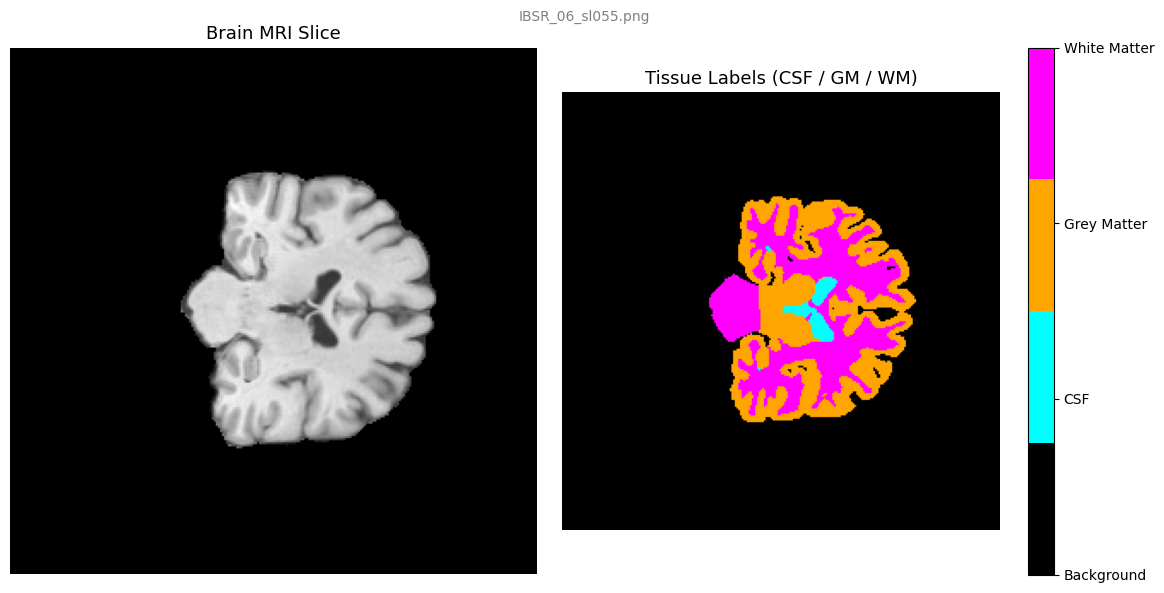

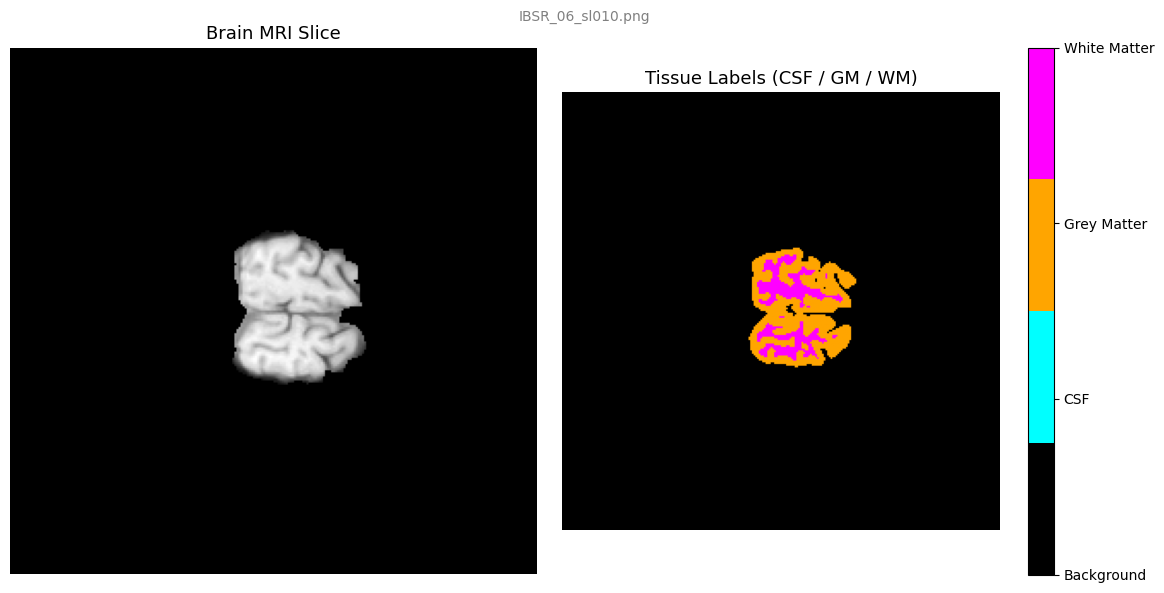

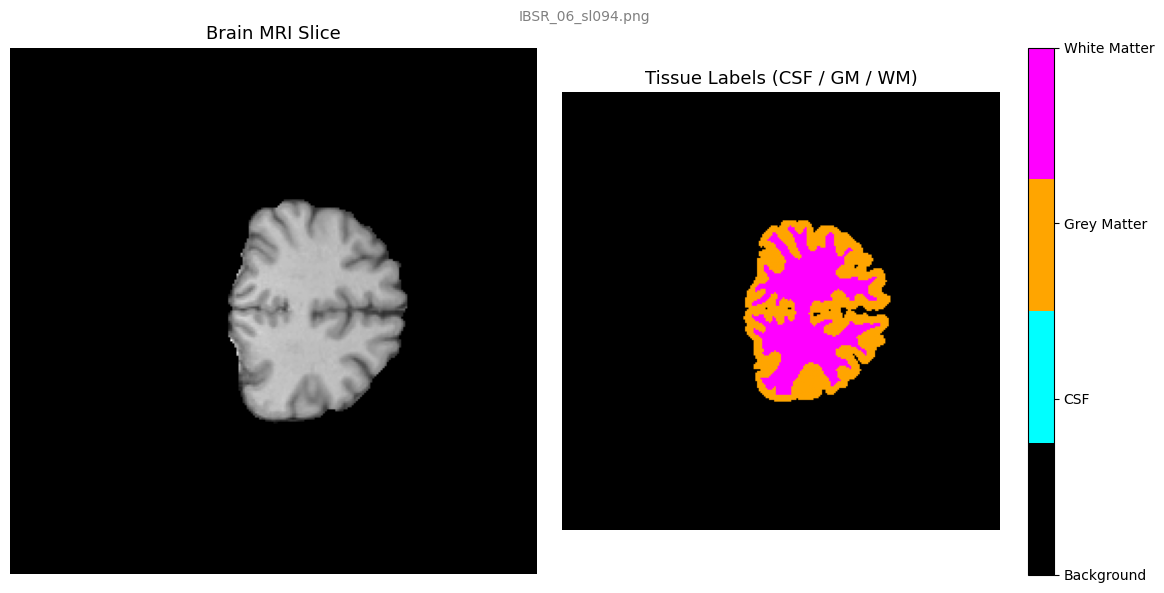

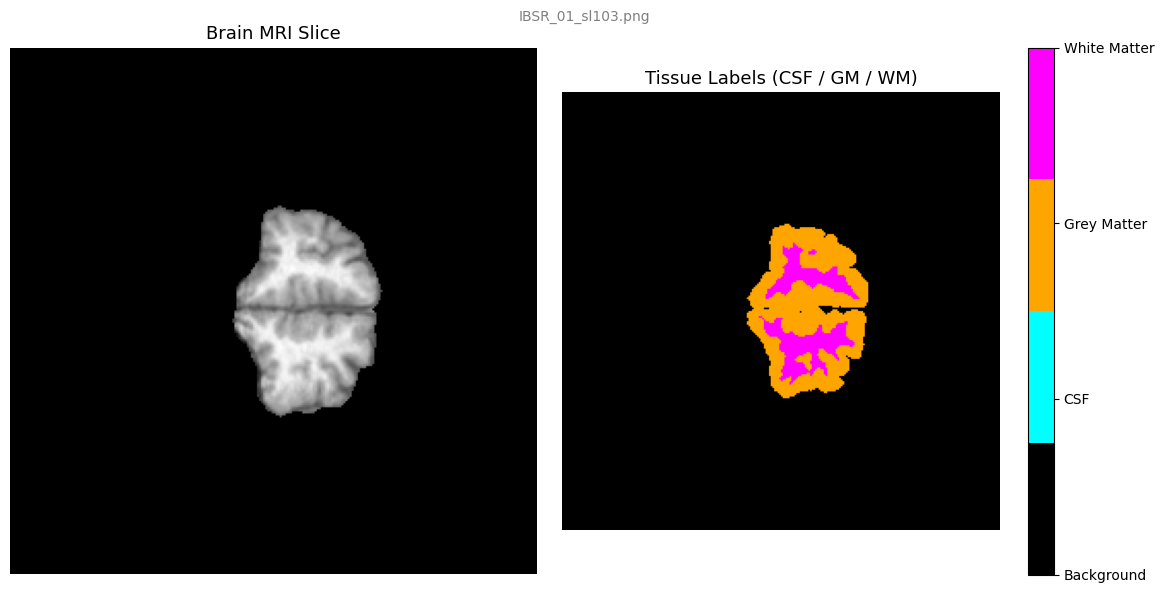

In [90]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample_multiclass(image_name, img_dir=IMAGE_FOLDER, mask_dir=MASK_FOLDER):
    img  = cv2.imread(os.path.join(img_dir,  image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(mask_dir, image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample_multiclass(random.choice(all_images))

## 5. Train / Test Split

In [91]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch! Check filenames.'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 200  |  Test: 36


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/36 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline — one-hot encoded masks

In [92]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)

    return img, mask


def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes →  images:', imgs.shape, ' masks:', masks.shape)

Datasets ready ✓
Batch shapes →  images: (16, 224, 224, 3)  masks: (16, 224, 224, 4)


## 8. Custom Metrics & Loss — categorical versions

In [93]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return K.mean(dice_per_class)


def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)


def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    iou_per_class = (intersection + smooth) / (total + smooth)
    return K.mean(iou_per_class)


def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    intersection = K.sum(t * p)
    union = K.sum(t) + K.sum(p) - intersection
    return (intersection + smooth) / (union + smooth)


def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    intersection = K.sum(t * p)
    union = K.sum(t) + K.sum(p) - intersection
    return (intersection + smooth) / (union + smooth)


def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    intersection = K.sum(t * p)
    union = K.sum(t) + K.sum(p) - intersection
    return (intersection + smooth) / (union + smooth)


def pixel_accuracy_multiclass(y_true, y_pred):
    true_labels = K.argmax(y_true, axis=-1)
    pred_labels = K.argmax(y_pred, axis=-1)
    correct = K.cast(K.equal(true_labels, pred_labels), K.floatx())
    return K.mean(correct)


def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass, pixel_accuracy_multiclass,
             csf_iou, gm_iou, wm_iou]
)

print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [94]:
model.summary()

try:
    tf.keras.utils.plot_model(
        model, to_file='segnet_multiclass_ibsr_architecture.png',
        show_shapes=True, show_layer_names=True, rankdir='TB', dpi=64
    )
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:150])

Model: "SegNet_MultiClass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1_c1 (Conv2D)                │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1_bn1 (BatchNormalization)   │ (None, 224, 224, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1_act1 (Activation)          │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1_c2 (Conv2D)                │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1_bn2 (BatchNormalization)   │ (None, 224, 224, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1_act2 (Activation)          │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2_c1 (Conv2D)                │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2_bn1 (BatchNormalization)   │ (None, 112, 112, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2_act1 (Activation)          │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2_c2 (Conv2D)                │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2_bn2 (BatchNormalization)   │ (None, 112, 112, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2_act2 (Activation)          │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_c1 (Conv2D)                │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_bn1 (BatchNormalization)   │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_act1 (Activation)          │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_c2 (Conv2D)                │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_bn2 (BatchNormalization)   │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_act2 (Activation)          │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_c3 (Conv2D)                │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_bn3 (BatchNormalization)   │ (None, 56, 56, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3_act3 (Activation)          │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 256)    │             

 Total params: 31,820,996 (121.39 MB)

 Trainable params: 31,804,100 (121.32 MB)

 Non-trainable params: 16,896 (66.00 KB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [95]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)


def colorize_mask(label_map):
    colors = np.array([[0,0,0], [0,255,255], [255,165,0], [255,0,255]], dtype=np.uint8)
    label_map = np.array(label_map).astype(int)
    return colors[label_map]


def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            gt_labels   = decode_mask(masks[i]).numpy()
            pred_labels = decode_mask(preds[i]).numpy()
            fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
            axes[0].imshow(imgs[i].numpy());            axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(gt_labels));   axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(pred_labels)); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()


class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')


logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_segnet_multiclass_ibsr.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]

print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


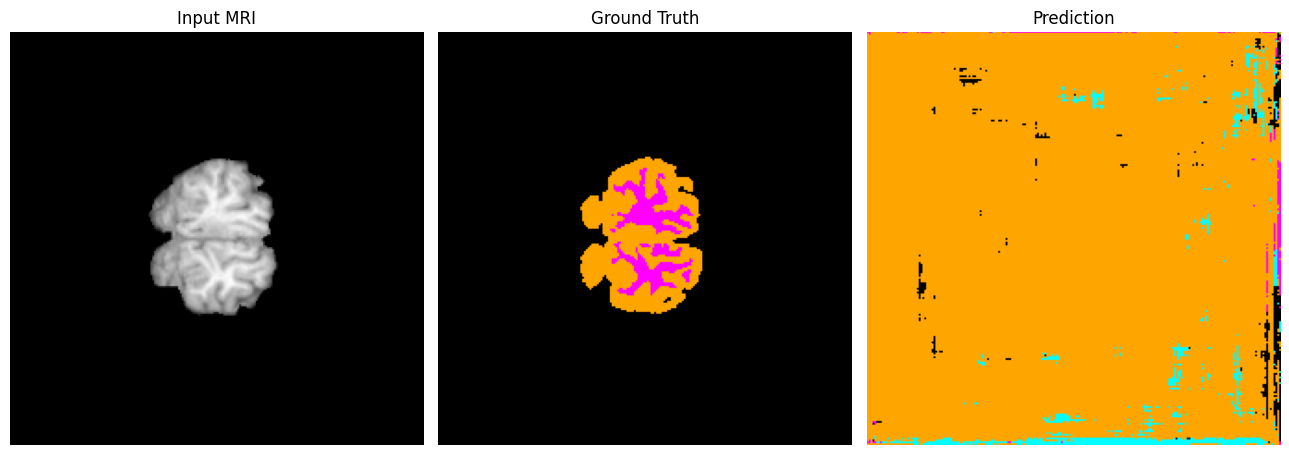

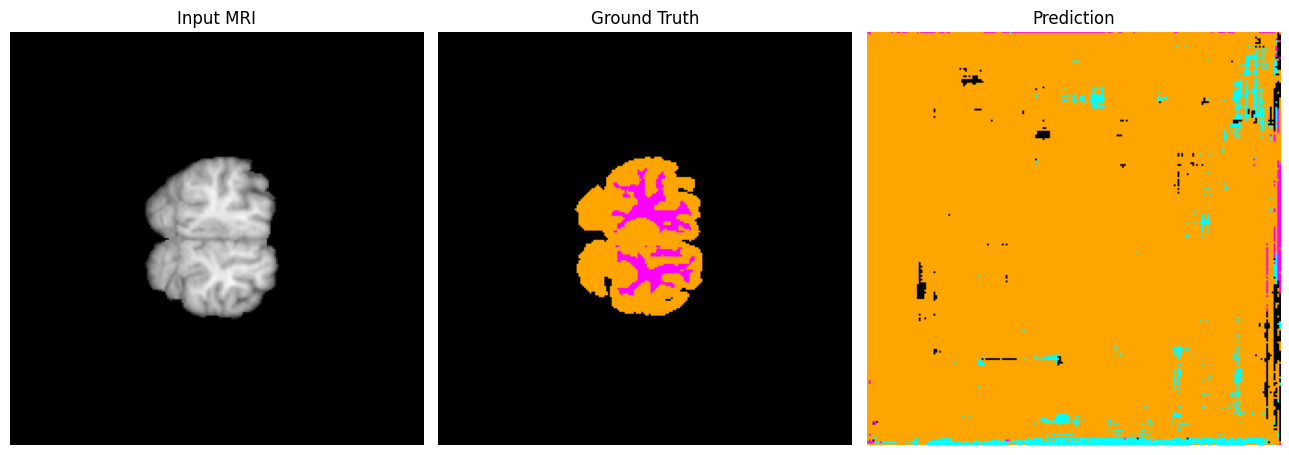

In [96]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 12
Validation steps : 2
Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - csf_iou: 0.0015 - dice_coefficient_multiclass: 0.2059 - gm_iou: 0.1299 - iou_score_multiclass: 0.1311 - loss: 2.1368 - pixel_accuracy_multiclass: 0.5289 - wm_iou: 0.0499
Epoch 1: val_iou_score_multiclass improved from None to 0.09567, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 1: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - csf_iou: 0.0013 - dice_coefficient_multiclass: 0.2444 - gm_iou: 0.1447 - iou_score_multiclass: 0.1634 - loss: 1.8246 - pixel_accuracy_multiclass: 0.7106 - wm_iou: 0.0653 - val_csf_iou: 0.0021 - val_dice_coefficient_multiclass: 0.1599 - val_gm_iou: 0.0716 - val_iou_score_multiclass: 0.0957 - val_loss: 2.1353 - val_pixel_accuracy_multiclass: 0.8569 - val_wm_iou: 0.0417 - learning_rate: 1.0000e-04
Epoch 2/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 3:38 20s/step - csf_iou: 1.8820e-05 - dice_coefficient_mul

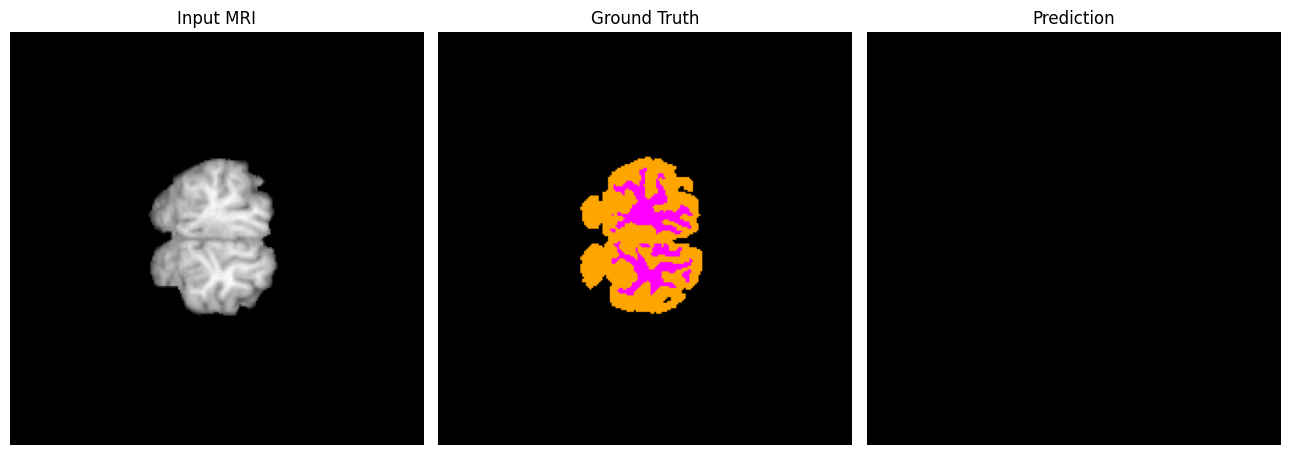

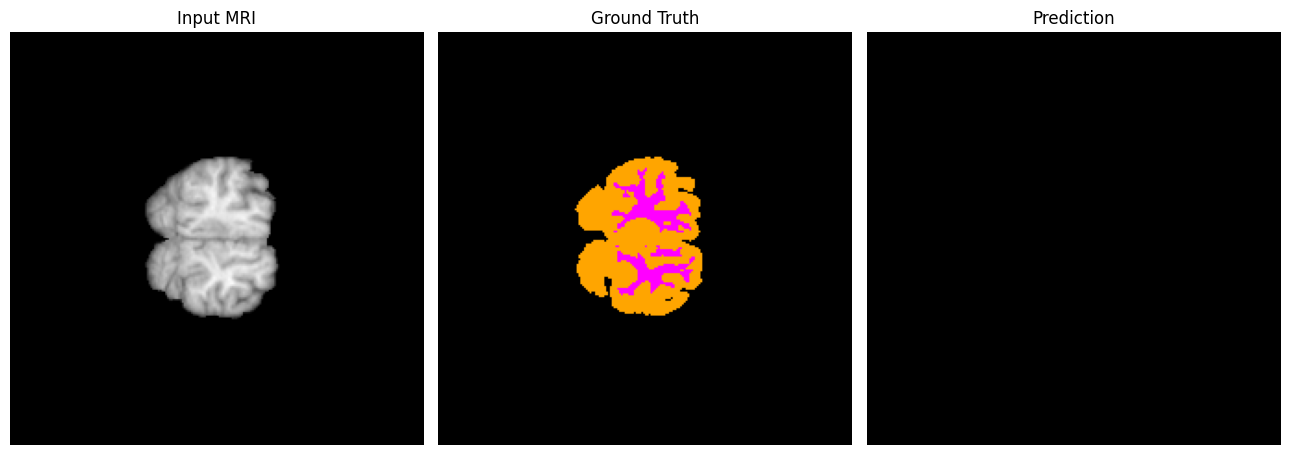

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.13786 to 0.13852, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 10: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 715ms/step - csf_iou: 2.6089e-05 - dice_coefficient_multiclass: 0.2688 - gm_iou: 0.1155 - iou_score_multiclass: 0.2109 - loss: 1.1717 - pixel_accuracy_multiclass: 0.9716 - wm_iou: 0.0200 - val_csf_iou: 0.0021 - val_dice_coefficient_multiclass: 0.2044 - val_gm_iou: 0.0624 - val_iou_score_multiclass: 0.1385 - val_loss: 1.6676 - val_pixel_accuracy_multiclass: 0.8569 - val_wm_iou: 0.0387 - learning_rate: 1.0000e-04
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - csf_iou: 0.0038 - dice_coefficient_multiclass: 0.4106 - gm_iou: 0.3124 - iou_score_multiclass: 0.3174 - loss: 0.9436 - pixel_accuracy_multiclass: 0.9352 - wm_iou: 0.1671
Epoch 11: val_iou_score_multiclass improved from 0.13852 to 0.14907, saving model to best_model_segn

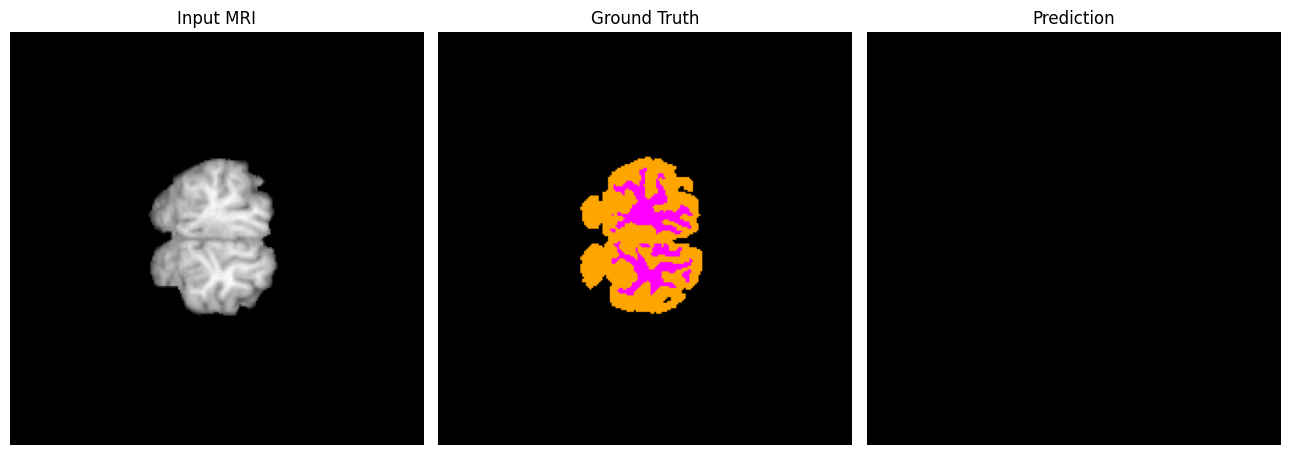

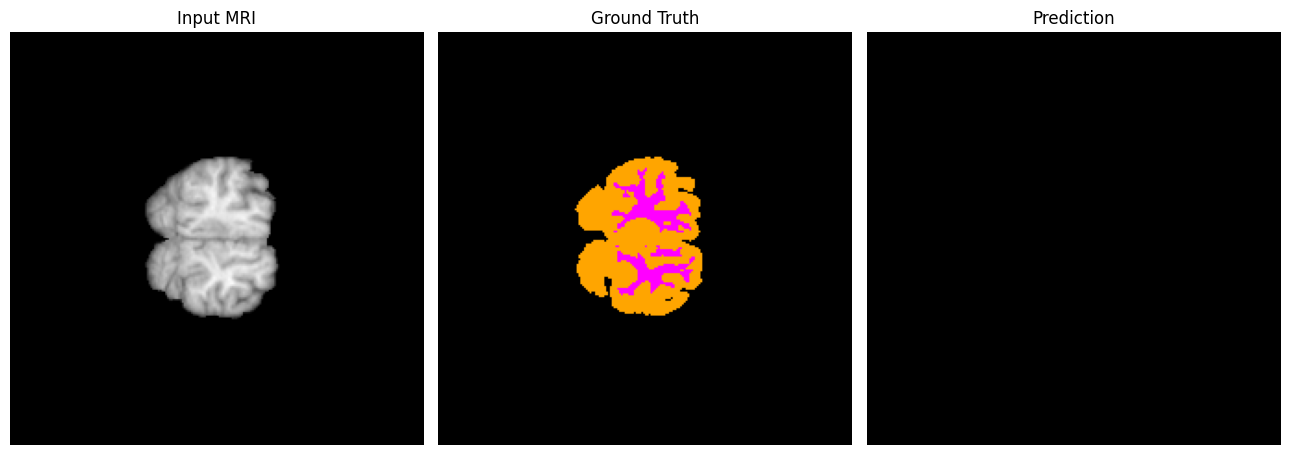

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass improved from 0.18109 to 0.18162, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 20: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 708ms/step - csf_iou: 3.4666e-05 - dice_coefficient_multiclass: 0.2969 - gm_iou: 0.1520 - iou_score_multiclass: 0.2384 - loss: 1.0216 - pixel_accuracy_multiclass: 0.9783 - wm_iou: 0.0256 - val_csf_iou: 0.0020 - val_dice_coefficient_multiclass: 0.2346 - val_gm_iou: 0.0446 - val_iou_score_multiclass: 0.1816 - val_loss: 1.3919 - val_pixel_accuracy_multiclass: 0.8569 - val_wm_iou: 0.0326 - learning_rate: 1.0000e-04
Epoch 21/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - csf_iou: 0.0107 - dice_coefficient_multiclass: 0.4473 - gm_iou: 0.3552 - iou_score_multiclass: 0.3514 - loss: 0.8442 - pixel_accuracy_multiclass: 0.9398 - wm_iou: 0.2090
Epoch 21: val_iou_score_multiclass improved from 0.18162 to 0.18478, saving model to best_model_segn

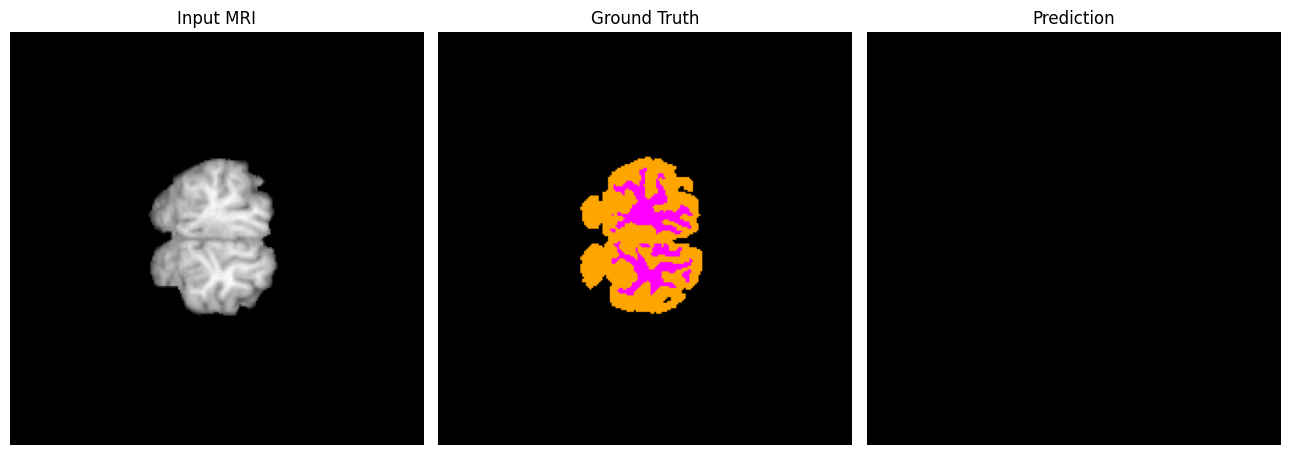

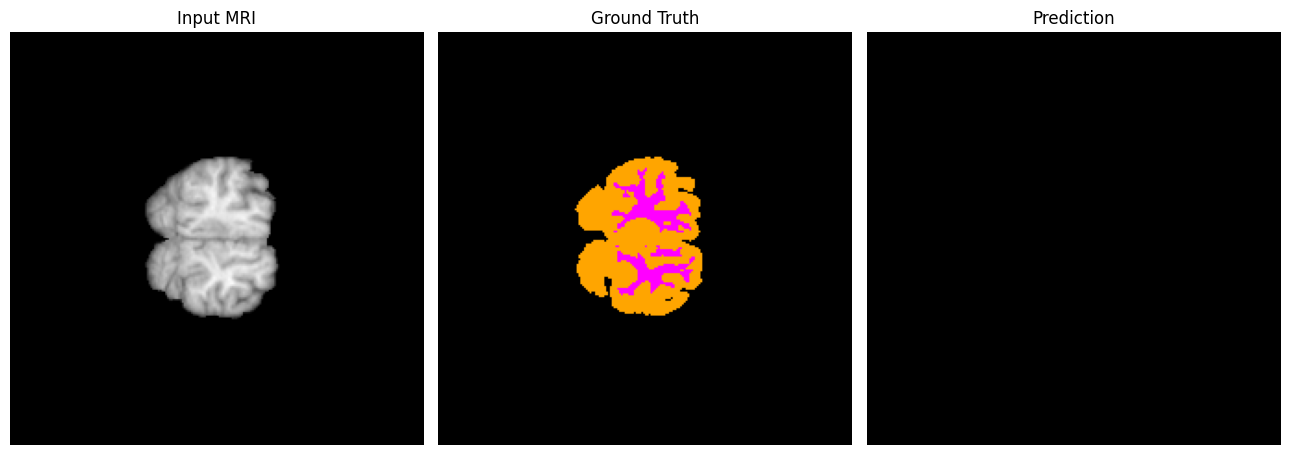

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass improved from 0.19859 to 0.19869, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 30: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 703ms/step - csf_iou: 4.1575e-05 - dice_coefficient_multiclass: 0.3186 - gm_iou: 0.1815 - iou_score_multiclass: 0.2583 - loss: 0.9301 - pixel_accuracy_multiclass: 0.9829 - wm_iou: 0.0353 - val_csf_iou: 0.0020 - val_dice_coefficient_multiclass: 0.2426 - val_gm_iou: 0.0350 - val_iou_score_multiclass: 0.1987 - val_loss: 1.3310 - val_pixel_accuracy_multiclass: 0.8569 - val_wm_iou: 0.0283 - learning_rate: 1.0000e-04
Epoch 31/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - csf_iou: 0.0219 - dice_coefficient_multiclass: 0.4850 - gm_iou: 0.4148 - iou_score_multiclass: 0.3869 - loss: 0.7533 - pixel_accuracy_multiclass: 0.9520 - wm_iou: 0.2482
Epoch 31: val_iou_score_multiclass improved from 0.19869 to 0.20036, saving model to best_model_segn

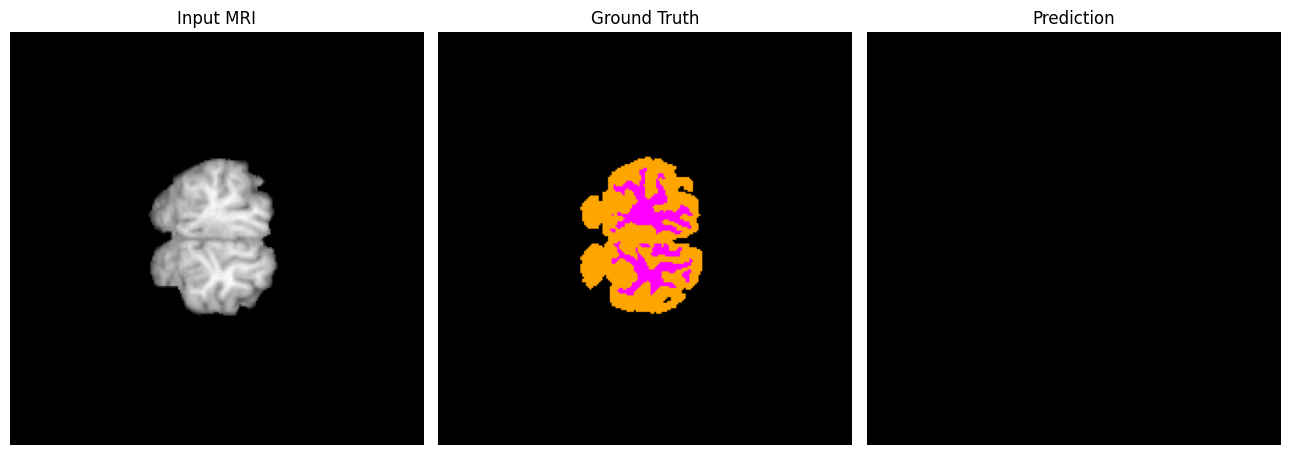

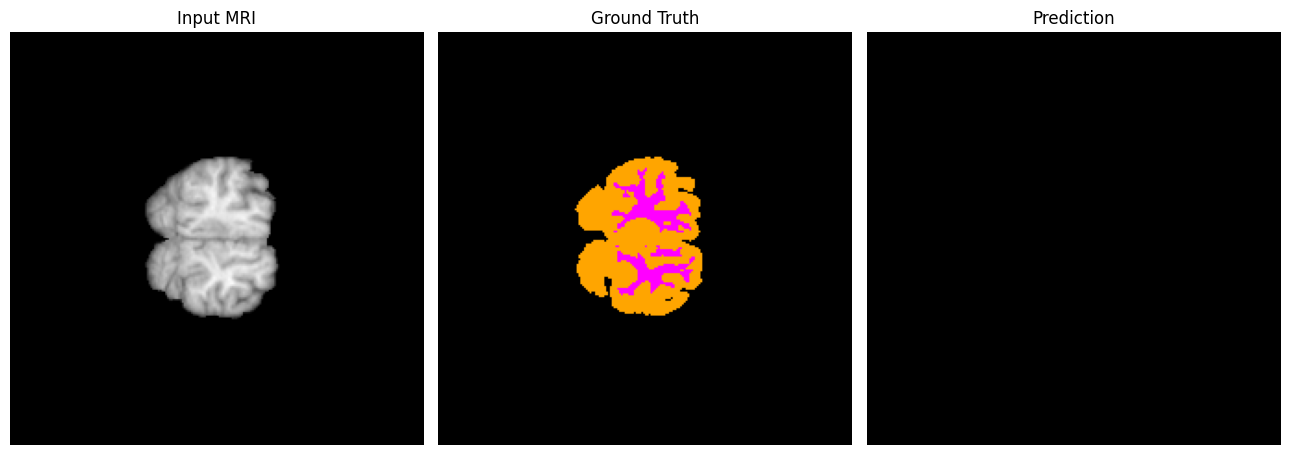

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass improved from 0.20624 to 0.20626, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 40: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 704ms/step - csf_iou: 4.8775e-05 - dice_coefficient_multiclass: 0.3377 - gm_iou: 0.2089 - iou_score_multiclass: 0.2748 - loss: 0.8761 - pixel_accuracy_multiclass: 0.9832 - wm_iou: 0.0474 - val_csf_iou: 0.0020 - val_dice_coefficient_multiclass: 0.2418 - val_gm_iou: 0.0234 - val_iou_score_multiclass: 0.2063 - val_loss: 1.3432 - val_pixel_accuracy_multiclass: 0.8569 - val_wm_iou: 0.0217 - learning_rate: 5.0000e-05
Epoch 41/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - csf_iou: 0.0316 - dice_coefficient_multiclass: 0.5142 - gm_iou: 0.4579 - iou_score_multiclass: 0.4147 - loss: 0.6928 - pixel_accuracy_multiclass: 0.9560 - wm_iou: 0.2872
Epoch 41: val_iou_score_multiclass improved from 0.20626 to 0.20699, saving model to best_model_segn

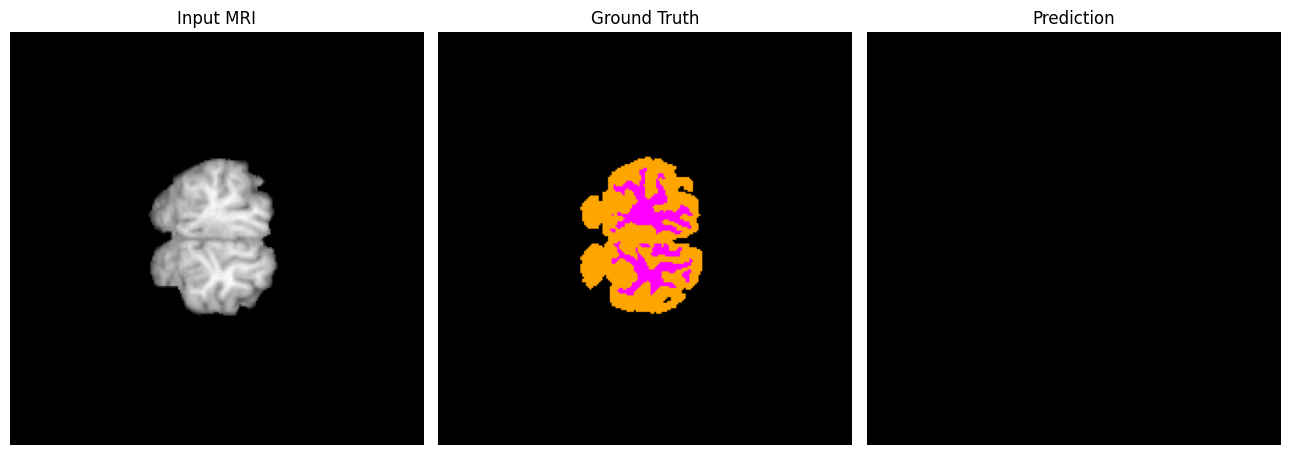

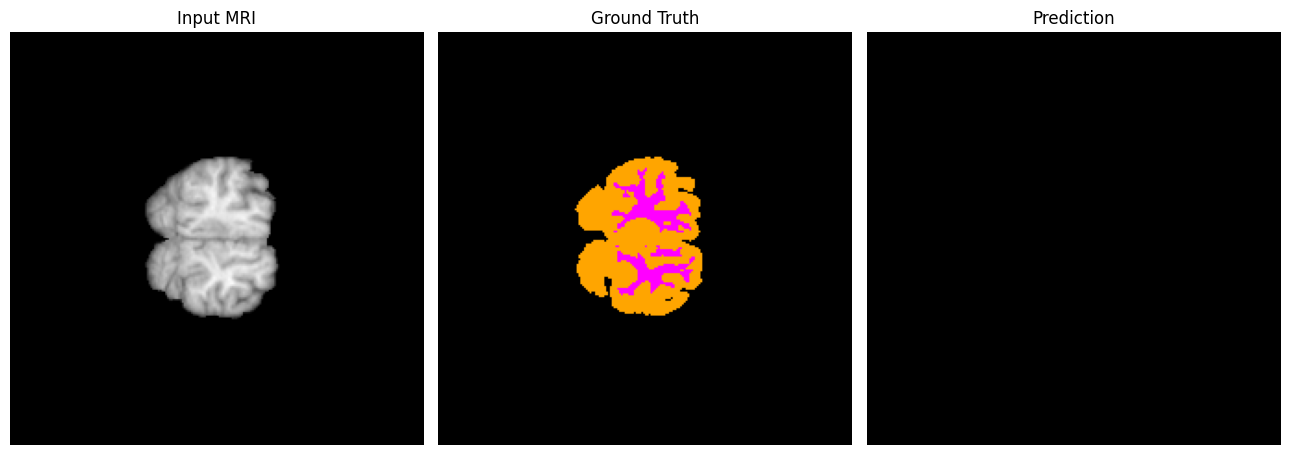

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass did not improve from 0.20811
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 565ms/step - csf_iou: 4.9941e-05 - dice_coefficient_multiclass: 0.3427 - gm_iou: 0.2227 - iou_score_multiclass: 0.2798 - loss: 0.8506 - pixel_accuracy_multiclass: 0.9884 - wm_iou: 0.0456 - val_csf_iou: 0.0019 - val_dice_coefficient_multiclass: 0.2413 - val_gm_iou: 0.0200 - val_iou_score_multiclass: 0.2081 - val_loss: 1.3538 - val_pixel_accuracy_multiclass: 0.8569 - val_wm_iou: 0.0200 - learning_rate: 1.2500e-05
Epoch 51/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - csf_iou: 0.0381 - dice_coefficient_multiclass: 0.5314 - gm_iou: 0.4926 - iou_score_multiclass: 0.4320 - loss: 0.6555 - pixel_accuracy_multiclass: 0.9634 - wm_iou: 0.3079
Epoch 51: val_iou_score_multiclass improved from 0.20811 to 0.20840, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 51: finished saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 51: ReduceLROnPlateau reducin

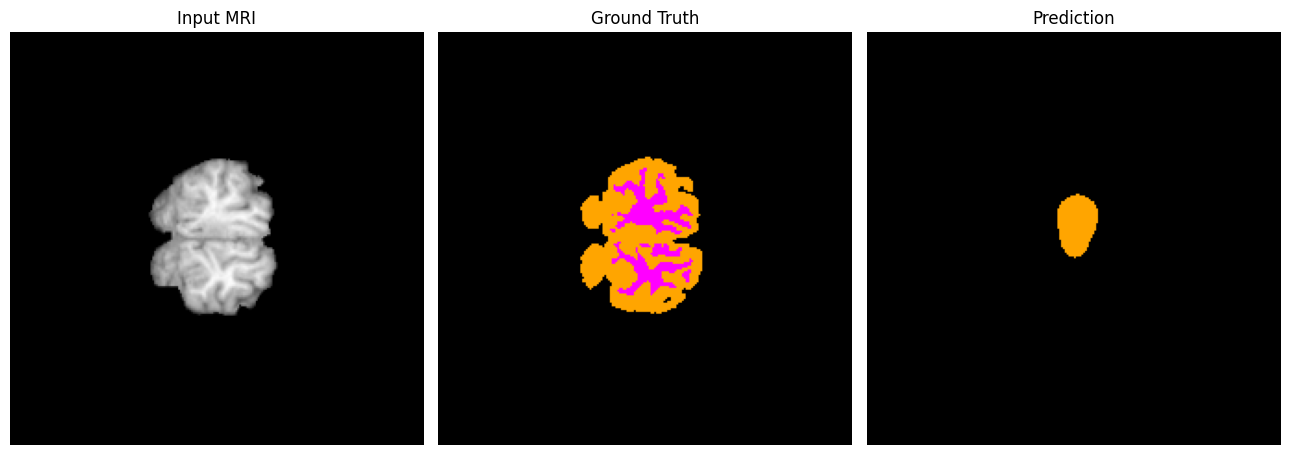

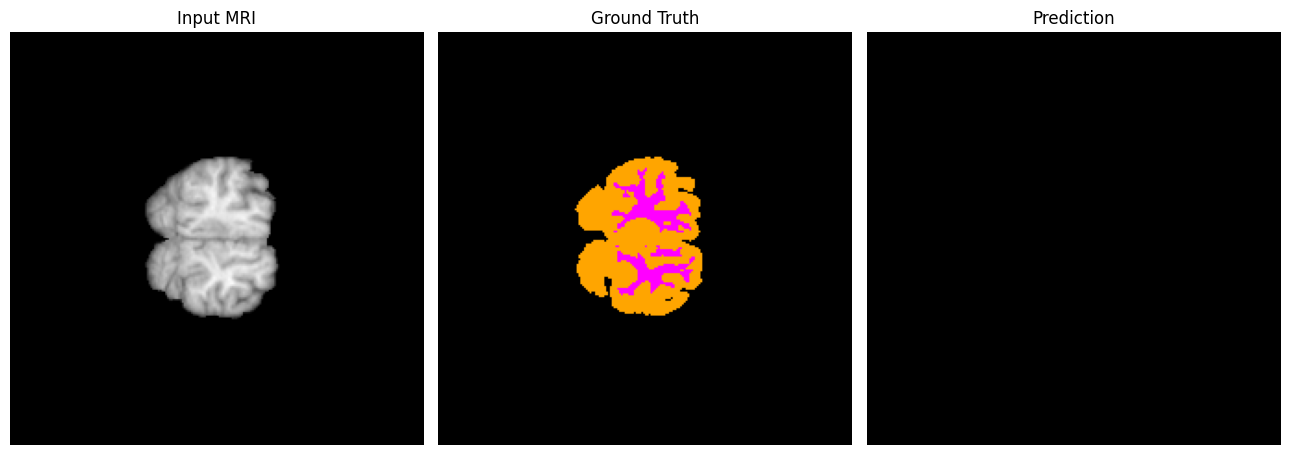

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass improved from 0.25205 to 0.25555, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 60: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 765ms/step - csf_iou: 5.0912e-05 - dice_coefficient_multiclass: 0.3445 - gm_iou: 0.2227 - iou_score_multiclass: 0.2811 - loss: 0.8472 - pixel_accuracy_multiclass: 0.9880 - wm_iou: 0.0488 - val_csf_iou: 0.0027 - val_dice_coefficient_multiclass: 0.3133 - val_gm_iou: 0.1227 - val_iou_score_multiclass: 0.2556 - val_loss: 1.1414 - val_pixel_accuracy_multiclass: 0.8728 - val_wm_iou: 0.0712 - learning_rate: 3.1250e-06
Epoch 61/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - csf_iou: 0.0401 - dice_coefficient_multiclass: 0.5350 - gm_iou: 0.4980 - iou_score_multiclass: 0.4353 - loss: 0.6487 - pixel_accuracy_multiclass: 0.9640 - wm_iou: 0.3122
Epoch 61: val_iou_score_multiclass improved from 0.25555 to 0.28304, saving model to best_model_segn

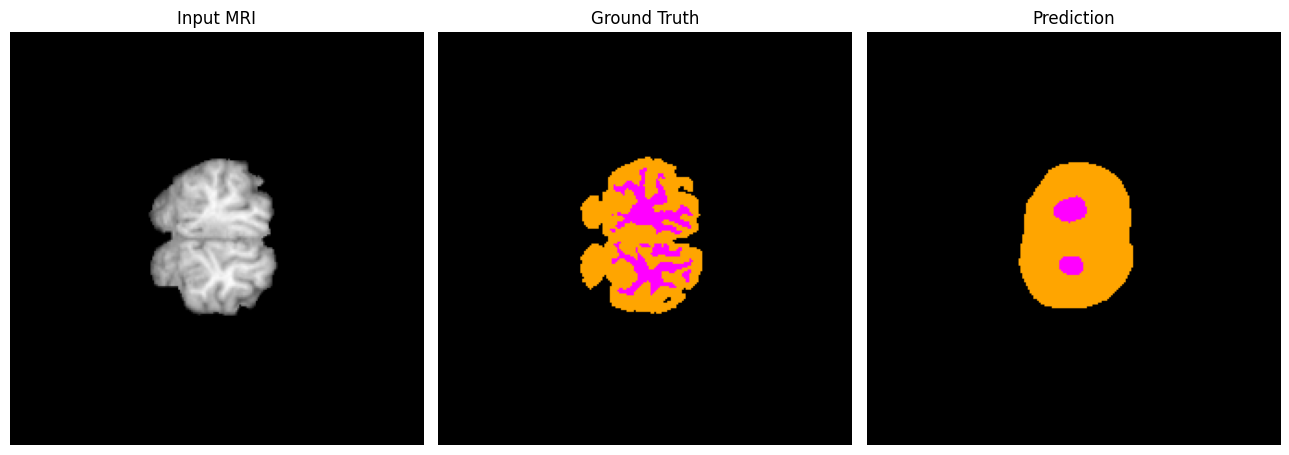

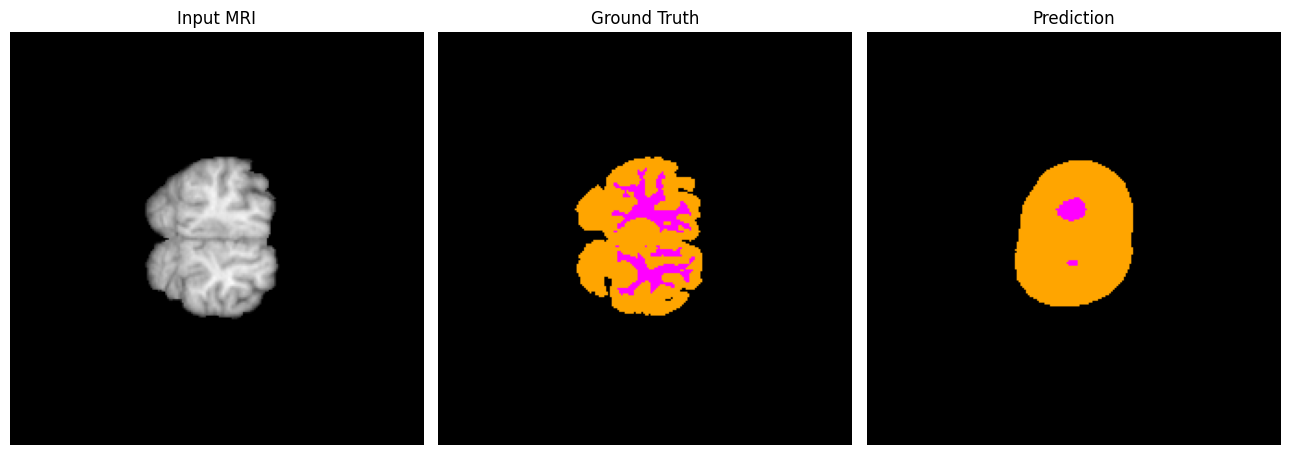

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass improved from 0.35621 to 0.35738, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 70: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 702ms/step - csf_iou: 5.0720e-05 - dice_coefficient_multiclass: 0.3446 - gm_iou: 0.2258 - iou_score_multiclass: 0.2815 - loss: 0.8445 - pixel_accuracy_multiclass: 0.9889 - wm_iou: 0.0465 - val_csf_iou: 6.8994e-04 - val_dice_coefficient_multiclass: 0.4358 - val_gm_iou: 0.4221 - val_iou_score_multiclass: 0.3574 - val_loss: 0.8081 - val_pixel_accuracy_multiclass: 0.9291 - val_wm_iou: 0.1144 - learning_rate: 3.1250e-06
Epoch 71/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - csf_iou: 0.0408 - dice_coefficient_multiclass: 0.5370 - gm_iou: 0.5012 - iou_score_multiclass: 0.4374 - loss: 0.6449 - pixel_accuracy_multiclass: 0.9646 - wm_iou: 0.3159
Epoch 71: val_iou_score_multiclass improved from 0.35738 to 0.36514, saving model to best_model_

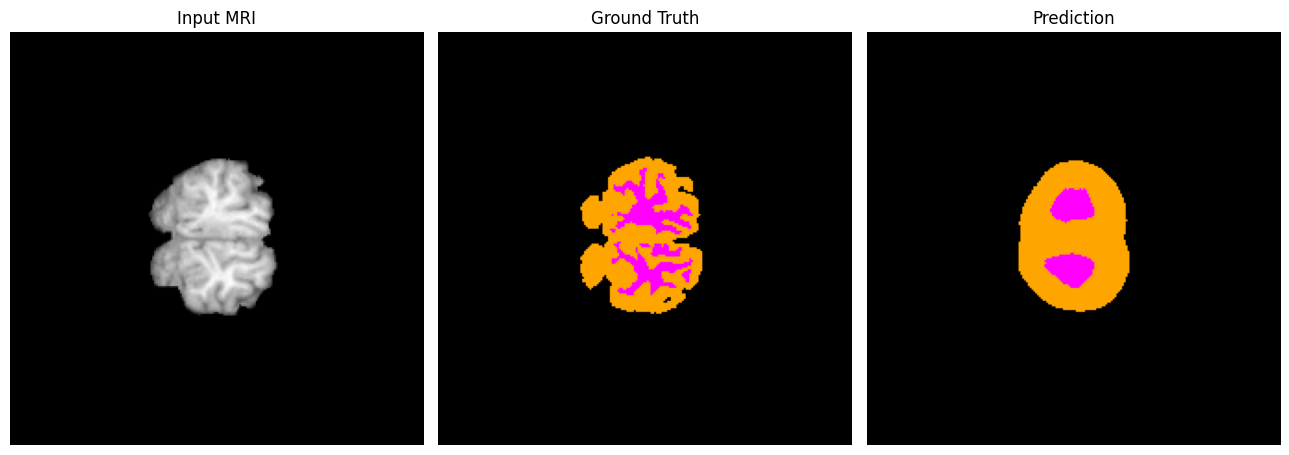

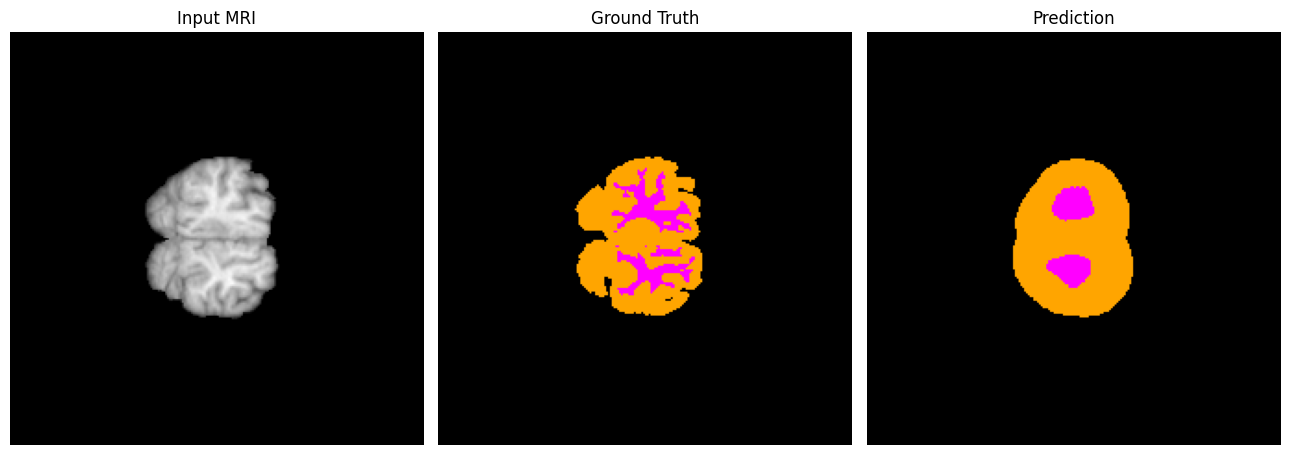

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass improved from 0.39657 to 0.39725, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 80: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 706ms/step - csf_iou: 5.1364e-05 - dice_coefficient_multiclass: 0.3460 - gm_iou: 0.2263 - iou_score_multiclass: 0.2825 - loss: 0.8419 - pixel_accuracy_multiclass: 0.9887 - wm_iou: 0.0490 - val_csf_iou: 0.0020 - val_dice_coefficient_multiclass: 0.4849 - val_gm_iou: 0.4858 - val_iou_score_multiclass: 0.3972 - val_loss: 0.7261 - val_pixel_accuracy_multiclass: 0.9450 - val_wm_iou: 0.2017 - learning_rate: 3.1250e-06
Epoch 81/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - csf_iou: 0.0422 - dice_coefficient_multiclass: 0.5395 - gm_iou: 0.5054 - iou_score_multiclass: 0.4398 - loss: 0.6405 - pixel_accuracy_multiclass: 0.9650 - wm_iou: 0.3189
Epoch 81: val_iou_score_multiclass improved from 0.39725 to 0.40414, saving model to best_model_segn

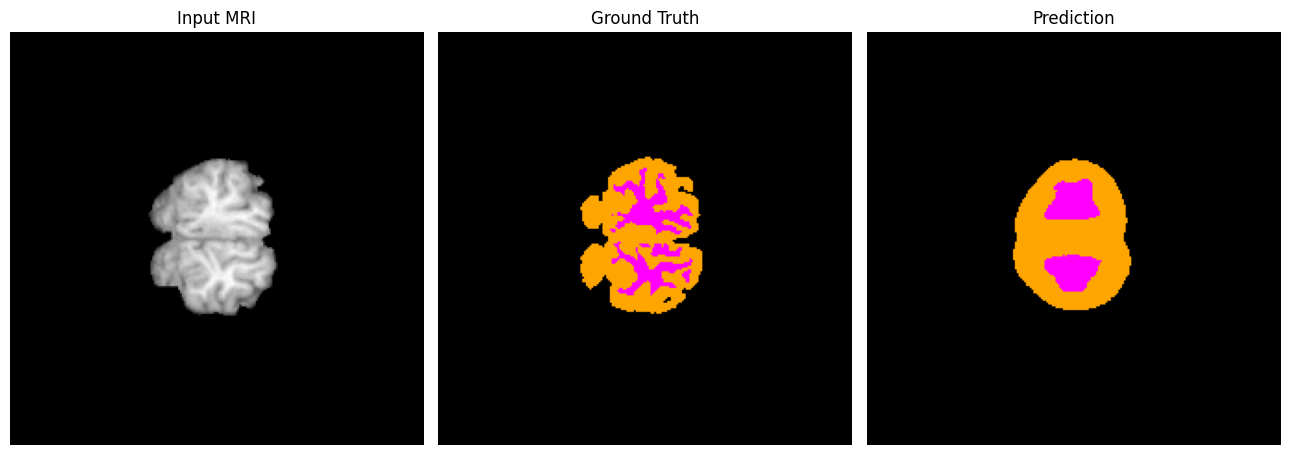

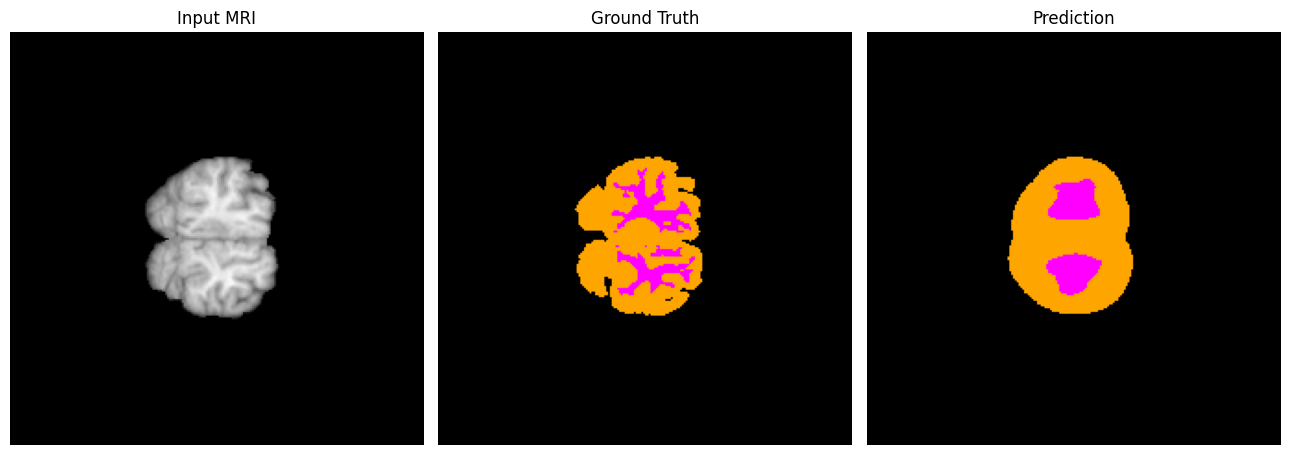

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass improved from 0.42888 to 0.42914, saving model to best_model_segnet_multiclass_ibsr.keras

Epoch 90: finished saving model to best_model_segnet_multiclass_ibsr.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 717ms/step - csf_iou: 5.1416e-05 - dice_coefficient_multiclass: 0.3468 - gm_iou: 0.2290 - iou_score_multiclass: 0.2832 - loss: 0.8399 - pixel_accuracy_multiclass: 0.9891 - wm_iou: 0.0486 - val_csf_iou: 0.0167 - val_dice_coefficient_multiclass: 0.5251 - val_gm_iou: 0.5148 - val_iou_score_multiclass: 0.4291 - val_loss: 0.6639 - val_pixel_accuracy_multiclass: 0.9544 - val_wm_iou: 0.2824 - learning_rate: 3.1250e-06
Epoch 91/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - csf_iou: 0.0428 - dice_coefficient_multiclass: 0.5411 - gm_iou: 0.5084 - iou_score_multiclass: 0.4414 - loss: 0.6383 - pixel_accuracy_multiclass: 0.9653 - wm_iou: 0.3213
Epoch 91: val_iou_score_multiclass improved from 0.42914 to 0.43290, saving model to best_model_segn

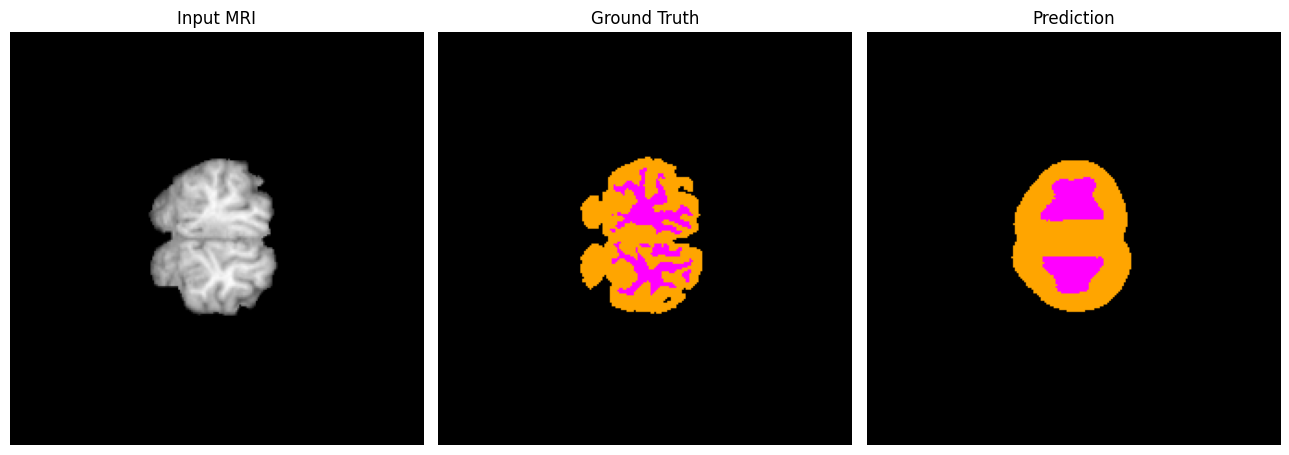

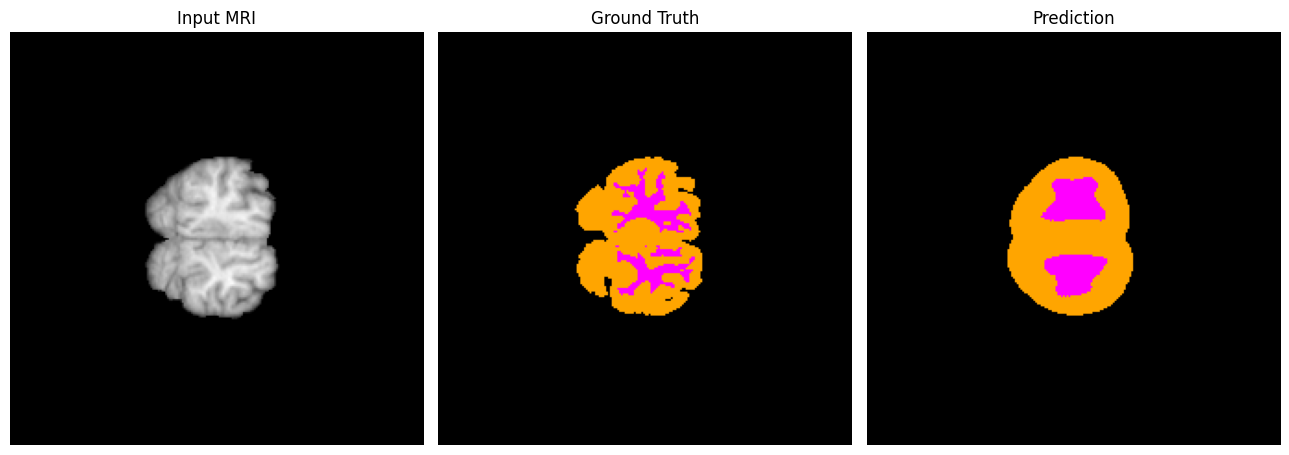

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.44456
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 564ms/step - csf_iou: 5.2026e-05 - dice_coefficient_multiclass: 0.3470 - gm_iou: 0.2290 - iou_score_multiclass: 0.2835 - loss: 0.8381 - pixel_accuracy_multiclass: 0.9889 - wm_iou: 0.0487 - val_csf_iou: 0.0298 - val_dice_coefficient_multiclass: 0.5445 - val_gm_iou: 0.5258 - val_iou_score_multiclass: 0.4445 - val_loss: 0.6362 - val_pixel_accuracy_multiclass: 0.9580 - val_wm_iou: 0.3194 - learning_rate: 3.1250e-06

Training time: 16.3 min


In [97]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()

history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)

elapsed = time.time() - start_time
print(f'\nTraining time: {elapsed/60:.1f} min')

## 13. Training Graphs

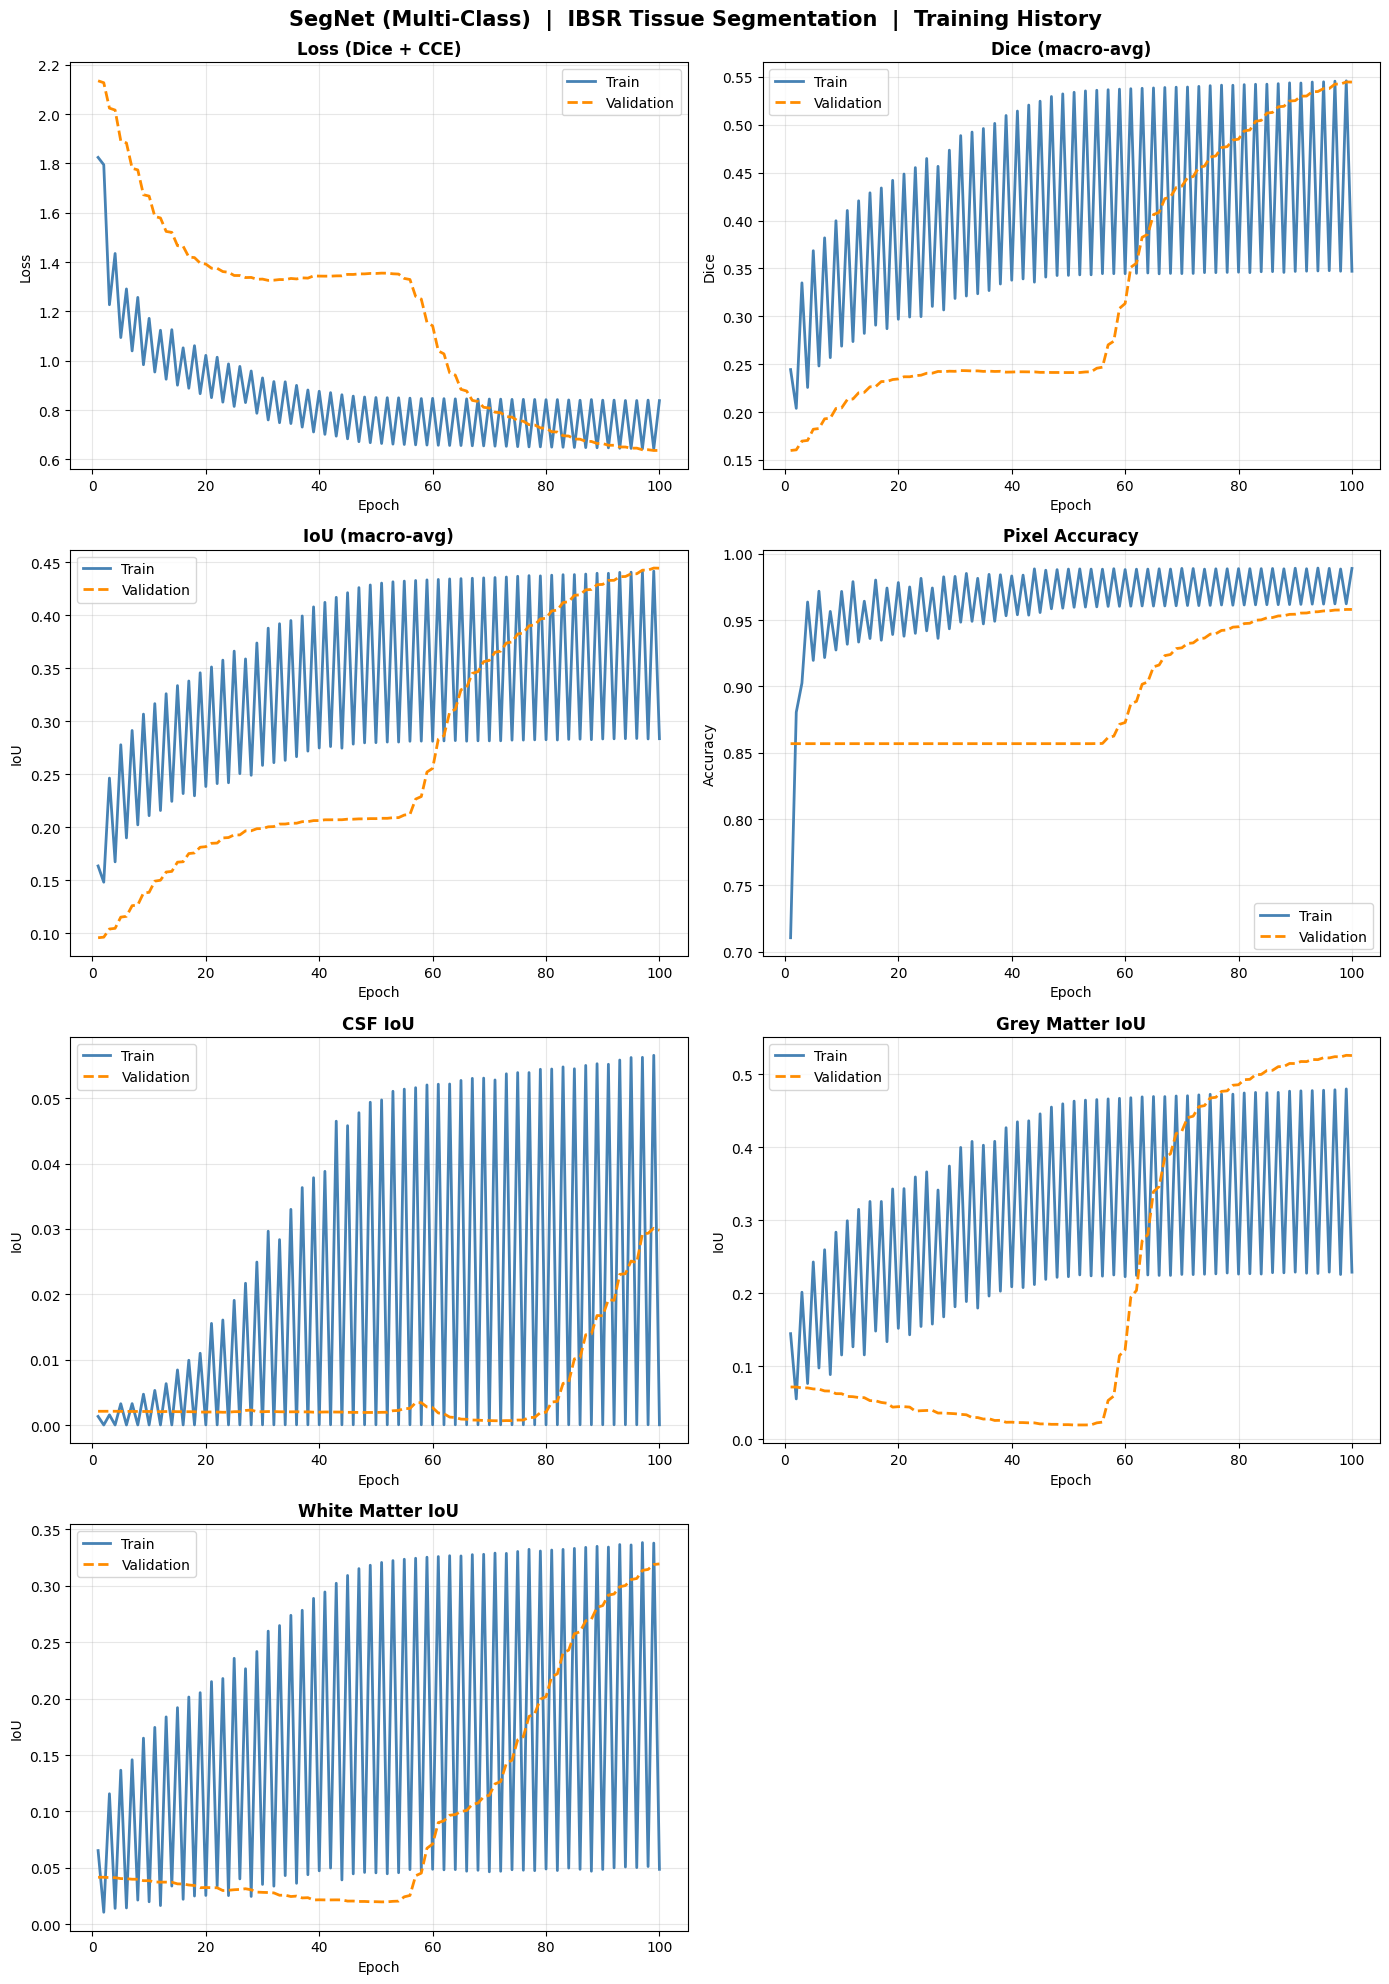

Plot saved ✓


In [98]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('SegNet (Multi-Class)  |  IBSR Tissue Segmentation  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (train_key, val_key, title, ylabel) in zip(axes.flatten(), plot_specs):
    epochs_range = range(1, len(H[train_key]) + 1)
    ax.plot(epochs_range, H[train_key], label='Train', color='steelblue', linewidth=2)
    ax.plot(epochs_range, H[val_key], label='Validation', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')

plt.tight_layout()
plt.savefig('training_history_segnet_multiclass_ibsr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [99]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 70)
print('   BEST & AVERAGE METRICS  —  SegNet Multi-Class  |  IBSR')
print('=' * 70)
print(report.to_string())
print('=' * 70)

best_epoch_iou = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch_iou})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')

report

   BEST & AVERAGE METRICS  —  SegNet Multi-Class  |  IBSR
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.6422     0.8529    0.6358   1.1683
Dice (macro-avg)      0.5458     0.4093    0.5446   0.3310
IoU (macro-avg)       0.4417     0.3283    0.4446   0.2673
Pixel Accuracy        0.9892     0.9640    0.9580   0.8904
CSF IoU               0.0566     0.0189    0.0301   0.0050
Grey Matter IoU       0.4800     0.3024    0.5261   0.2074
White Matter IoU      0.3383     0.1588    0.3194   0.1014

Best Val IoU (macro-avg): 0.4446  (epoch 99)
Best Val CSF IoU         : 0.0301
Best Val Grey Matter IoU : 0.5261
Best Val White Matter IoU: 0.3194


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.6422,0.8529,0.6358,1.1683
Dice (macro-avg),0.5458,0.4093,0.5446,0.3310
IoU (macro-avg),0.4417,0.3283,0.4446,0.2673
Pixel Accuracy,0.9892,0.9640,0.9580,0.8904
CSF IoU,0.0566,0.0189,0.0301,0.0050
Grey Matter IoU,0.4800,0.3024,0.5261,0.2074
White Matter IoU,0.3383,0.1588,0.3194,0.1014


## 15. Load Best Model & Final Evaluation

In [100]:
best_model = tf.keras.models.load_model(
    'best_model_segnet_multiclass_ibsr.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [101]:
print('Evaluating best model on held-out test set...\n')
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (SegNet Multi-Class | IBSR)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

final_df = pd.DataFrame([{
    'Model': 'SegNet Multi-Class (IBSR)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')
final_df

Evaluating best model on held-out test set...

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - csf_iou: 0.0182 - dice_coefficient_multiclass: 0.5440 - gm_iou: 0.5459 - iou_score_multiclass: 0.4473 - loss: 0.6303 - pixel_accuracy_multiclass: 0.9593 - wm_iou: 0.3207

2026-06-29 11:23:47.713471: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 11:23:47.945859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - csf_iou: 0.0201 - dice_coefficient_multiclass: 0.5064 - gm_iou: 0.4678 - iou_score_multiclass: 0.4133 - loss: 0.6427 - pixel_accuracy_multiclass: 0.9656 - wm_iou: 0.2594  

  FINAL TEST-SET METRICS  (SegNet Multi-Class | IBSR)
  loss                               : 0.6427
  compile_metrics                    : 0.5064


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
SegNet Multi-Class (IBSR),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

Test set predictions:


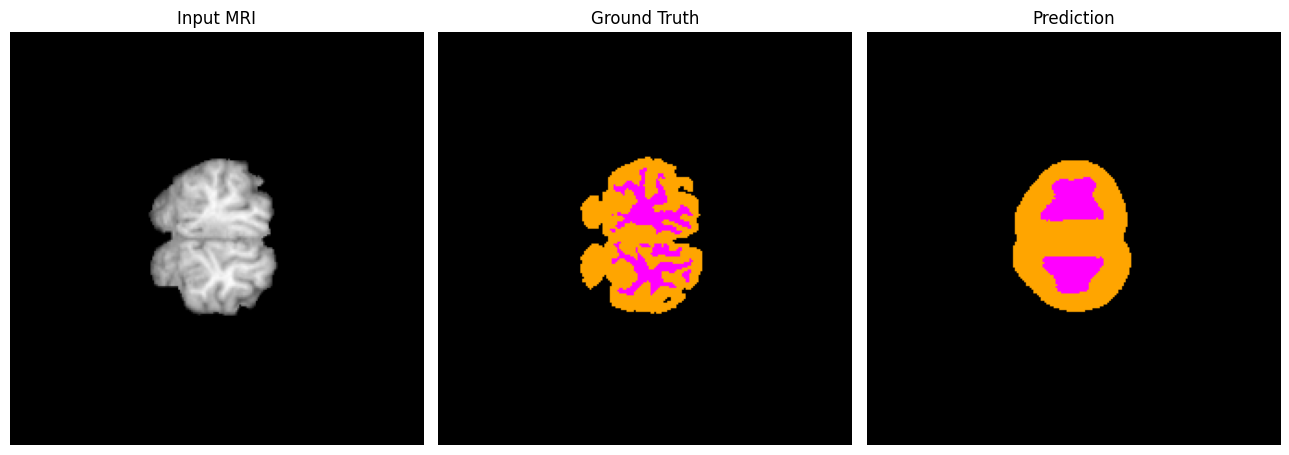

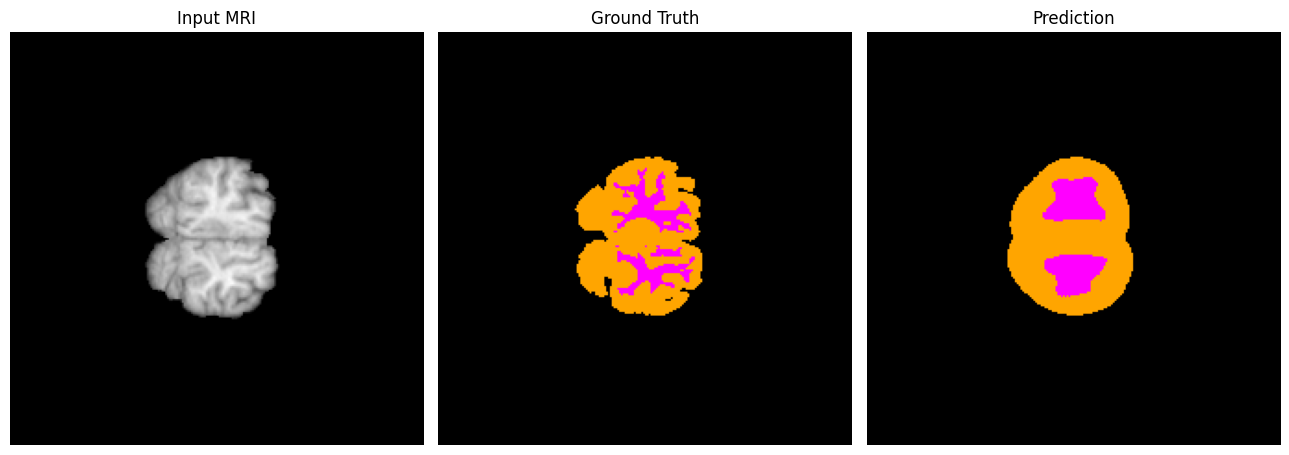

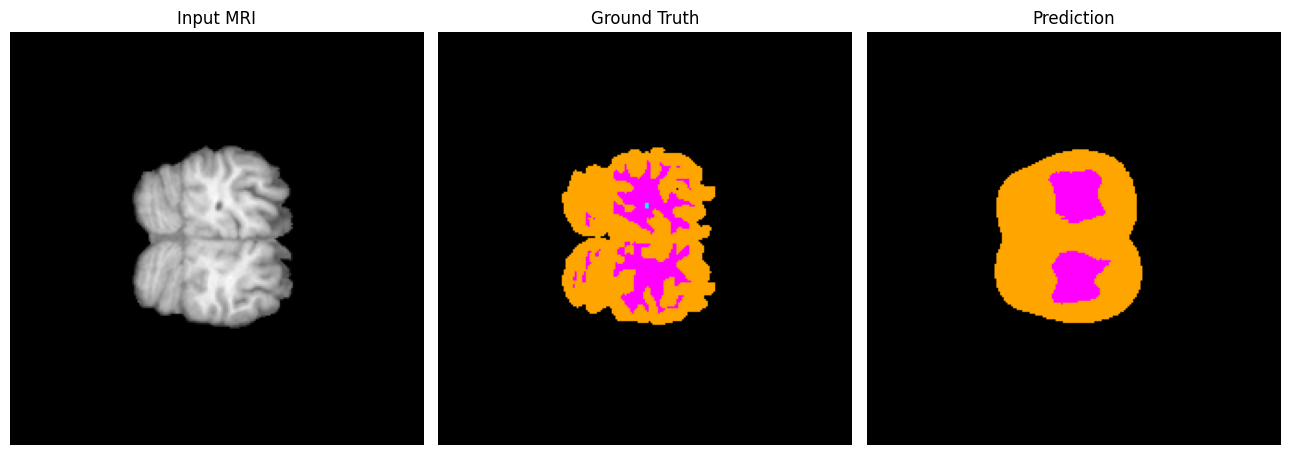

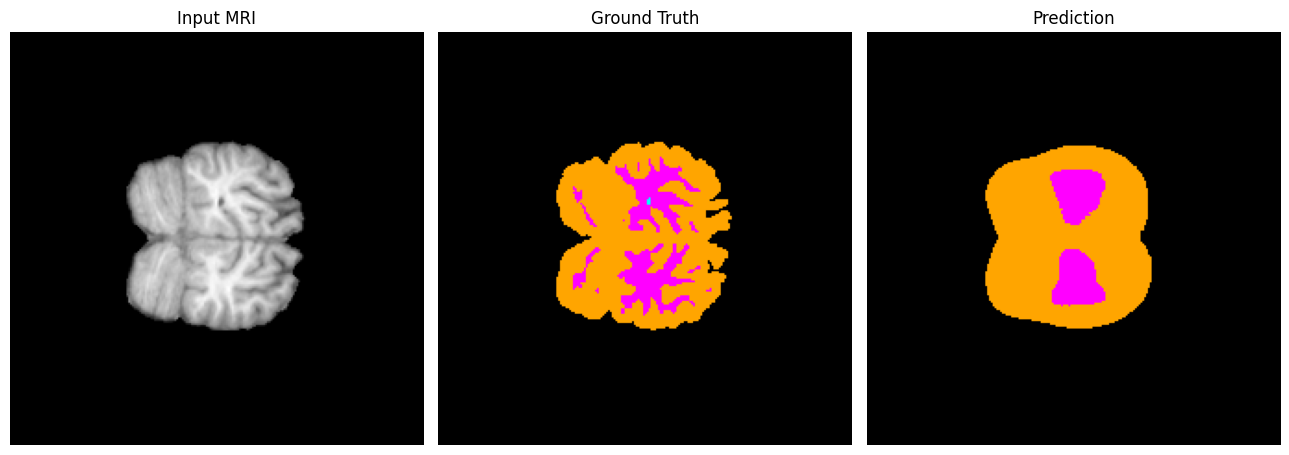

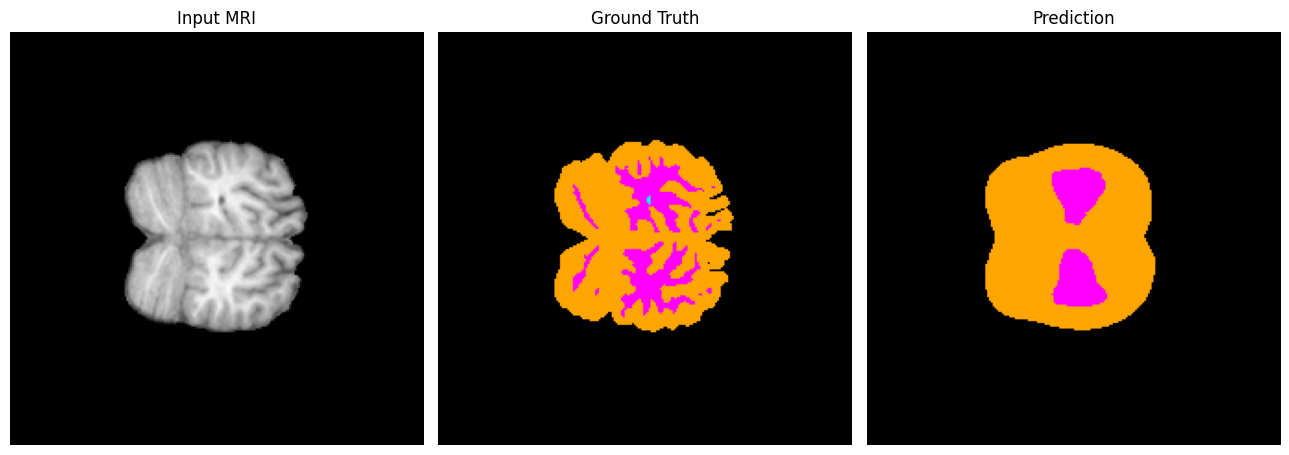

In [102]:
print('Test set predictions:')
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [103]:
best_model.save('ibsr_segnet_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
